In [2]:
library("dplyr")
library("pomp")

Warning message:
"package 'dplyr' was built under R version 4.4.3"

Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union




In [54]:
logit_transform <- function(array) {
    return(log(array/(1-array)))
    }


ll_df    <- read.csv("data/results.csv")
ll_df    <- ll_df %>% filter(bEP >= -1 & bEP <= 1)  -> ll_df
ll_df    <- ll_df %>% filter(loglik.se < 2) -> ll_df
ll_df    <- ll_df %>% arrange(desc(loglik)) -> ll_df
mle_pars <- ll_df[1,]$loglik
ll_df    <- ll_df %>% filter(loglik > (mle_pars - 50)) -> ll_df

ll_df$rho_trans <- logit_transform(ll_df$rho)

In [65]:
levels <- c(0.9, 0.75, 0.5)
params <- c("rho_trans", "bEP", "bCP")

mcap_all_df <- data.frame(parameter = numeric(), loglik = numeric(), smoothed = numeric(), ci_low = numeric(), ci_high = numeric(), mle = numeric(), span = numeric())
for (par in params)
{
    for (span_sm in levels)
    {
        mcap_r  <- mcap(ll_df$loglik, ll_df[[par]], level = 0.95, span = span_sm, Ngrid = 1000)

        mle      <- mcap_r$mle
        sm_ll_df <- mcap_r$fit
        param    <- mcap_r$param
        ci       <- mcap_r$ci

        sm_ll_df$ci_low  <- mcap_r$ci[1]
        sm_ll_df$ci_high <- mcap_r$ci[2]
        sm_ll_df$mle  <- mle
        sm_ll_df$span      <- span_sm
        sm_ll_df$param_name <- par

        mcap_all_df <- rbind(mcap_all_df, sm_ll_df)
    }
}


In [66]:

write.csv(mcap_all_df, "./data/mcap_r_results.csv", row.names = FALSE)


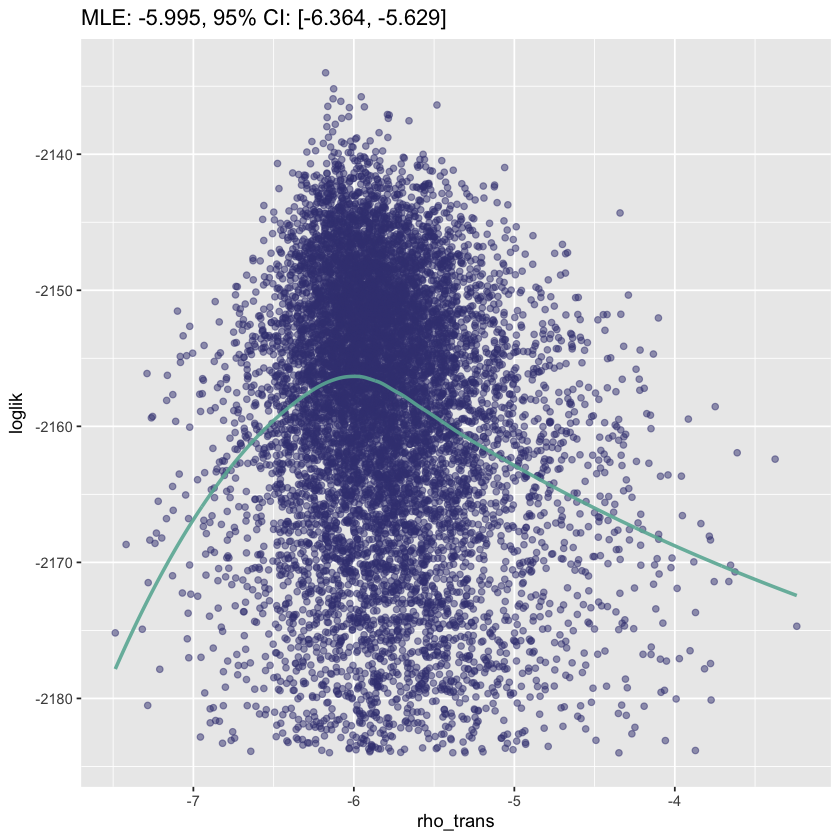

In [ ]:
library("ggplot2")

#plot(x = sm_ll_df$parameter, y = sm_ll_df$smoothed, ylab = "loglik")
#+ theme(plot_background= element_rect(fill='lightblue', color='lightblue'))
title <- sprintf("MLE: %.3f, 95%% CI: [%.3f, %.3f]", mle, ci[1], ci[2])
ggplot(sm_ll_df, aes(x=parameter, y=smoothed)) +
        geom_point(aes(x = rho_trans, y = loglik), data=ll_df, color="#404080", alpha=0.5) +
        geom_line(color="#69b3a2", linewidth=1, alpha=0.9, linetype=1) +
        ggtitle(title)

# geom_line(aes(x = parameter, y = quadratic),  color="#972b10", alpha=0.5) +


In [9]:
ci[1]

[1] -0.07466323